# Primena algoritama mašinskog učenja u proceni izloženosti zanimanja generativnoj veštačkoj inteligenciji


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

from scipy.stats import spearmanr
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor

import shap
from lime.lime_tabular import LimeTabularExplainer

In [20]:
import os
os.makedirs('slike', exist_ok=True)

## 1. Učitavanje podataka


In [21]:
occ = pd.read_csv('occ_level.csv')
skills = pd.read_csv('occupations_onet_basic_skills.csv')
work = pd.read_csv('occupations_onet_work_contexts.csv')

In [22]:
occ.head()

,O*NET-SOC Code,Title,dv_rating_alpha,dv_rating_beta,dv_rating_gamma,human_rating_alpha,human_rating_beta,human_rating_gamma
0,11-1011.00,Chief Executives,0.100000,0.460000,0.820000,0.180000,0.350000,0.520000
1,11-1011.03,Chief Sustainability Officers,0.166667,0.555556,0.944444,0.055556,0.388889,0.722222
2,11-1021.00,General and Operations Managers,0.000000,0.480769,0.961538,0.115385,0.384615,0.653846
3,11-1031.00,Legislators,0.033333,0.400000,0.766667,0.266667,0.516667,0.766667
4,11-2011.00,Advertising and Promotions Managers,0.000000,0.476744,0.953488,0.255814,0.546512,0.837209


In [23]:
skills.head()

,Occupation,Job Zone,Active_Learning_Importance,Active_Learning_Level,Critical_Thinking_Importance,Critical_Thinking_Level,Learning_Strategies_Importance,Learning_Strategies_Level,Monitoring_Importance,Monitoring_Level,...,Programming_Importance,Programming_Level,Reading_Comprehension_Importance,Reading_Comprehension_Level,Science_Importance,Science_Level,Speaking_Importance,Speaking_Level,Writing_Importance,Writing_Level
0,"Judges, Magistrate Judges, and Magistrates",5,75,66,97,82,44,41,72,59,...,6,Not relevant,81,68,19,20,78,70,78,70
1,Marriage and Family Therapists,5,69,61,72,61,53,54,66,57,...,6,Not relevant,75,61,38,41,81,61,75,61
2,"Child, Family, and School Social Workers",4,60,54,78,61,53,45,72,55,...,10,7,75,59,31,29,88,59,69,59
3,Mental Health Counselors,5,63,59,69,64,56,55,72,57,...,16,9,78,66,47,50,81,61,75,61
4,Psychiatrists,5,75,63,81,66,69,57,75,59,...,13,9,78,71,72,59,81,63,78,63


In [24]:
work.head()

,degree_of_automation_context,occupation,importance_of_being_exact_or_accurate_context,importance_of_repeating_same_tasks_context,structured_versus_unstructured_work_context
0,0.70,Travel Agents,0.95,0.53,0.83
1,0.68,"Postal Service Mail Sorters, Processors, and P...",0.76,0.67,0.53
2,0.67,Medical and Clinical Laboratory Technologists,1.00,0.85,0.81
3,0.66,Chemical Plant and System Operators,0.87,0.76,0.64
4,0.66,Telephone Operators,0.93,0.97,0.27


In [25]:
print(occ.info())
print(skills.info())
print(work.info())

<class 'pandas.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   O*NET-SOC Code      923 non-null    str    
 1   Title               923 non-null    str    
 2   dv_rating_alpha     923 non-null    float64
 3   dv_rating_beta      923 non-null    float64
 4   dv_rating_gamma     923 non-null    float64
 5   human_rating_alpha  923 non-null    float64
 6   human_rating_beta   923 non-null    float64
 7   human_rating_gamma  923 non-null    float64
dtypes: float64(6), str(2)
memory usage: 57.8 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 873 entries, 0 to 872
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Occupation                        873 non-null    str  
 1   Job Zone                          873 non-null    int64
 2   Active_Learning_Impo

In [26]:
occ.isna().sum()

O*NET-SOC Code        0
Title                 0
dv_rating_alpha       0
dv_rating_beta        0
dv_rating_gamma       0
human_rating_alpha    0
human_rating_beta     0
human_rating_gamma    0
dtype: int64

In [27]:
occ.describe()

,dv_rating_alpha,dv_rating_beta,dv_rating_gamma,human_rating_alpha,human_rating_beta,human_rating_gamma
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,0.141813,0.344732,0.547652,0.144119,0.302671,0.461223
std,0.165965,0.221262,0.345244,0.144725,0.207423,0.296896
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040816,0.144949,0.199834,0.000000,0.109375,0.185129
50%,0.096774,0.361111,0.600000,0.115385,0.306452,0.458333
75%,0.181818,0.500000,0.875000,0.235294,0.472475,0.727273
max,1.000000,1.000000,1.000000,0.800000,0.843750,1.000000


## 2. Čišćenje i priprema podataka



In [28]:
# Provera placeholder vrednosti 
print("Not relevant:",
      (skills == 'Not relevant').sum().sum())

print("Not available:",
      (skills == 'Not available').sum().sum())

# Not relevant -> 0
# Not available -> NaN
skills = skills.replace({
    'Not relevant': 0,
    'Not available': np.nan
})

for col in skills.columns:
    if col != 'Occupation':
        skills[col] = pd.to_numeric(skills[col], errors='coerce')

print("\nNedostajuće vrednosti:")
print(skills.isna().sum()[skills.isna().sum() > 0])

Not relevant: 532
Not available: 28

Nedostajuće vrednosti:
Mathematics_Level     2
Programming_Level    11
Science_Level        15
dtype: int64


In [29]:
skills.describe(include='all')

,Occupation,Job Zone,Active_Learning_Importance,Active_Learning_Level,Critical_Thinking_Importance,Critical_Thinking_Level,Learning_Strategies_Importance,Learning_Strategies_Level,Monitoring_Importance,Monitoring_Level,...,Programming_Importance,Programming_Level,Reading_Comprehension_Importance,Reading_Comprehension_Level,Science_Importance,Science_Level,Speaking_Importance,Speaking_Level,Writing_Importance,Writing_Level
count,873,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,...,873.000000,862.000000,873.000000,873.000000,873.000000,858.000000,873.000000,873.000000,873.000000,873.000000
unique,873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,"Judges, Magistrate Judges, and Magistrates",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.192440,52.994273,45.602520,63.037801,51.005727,44.616266,40.633448,57.666667,48.269187,...,14.979381,11.004640,61.757159,52.044674,24.704467,20.650350,63.577320,49.391753,54.565865,47.054983
std,NaN,1.169995,12.843044,11.055068,11.262290,9.081245,14.227366,11.148122,9.650902,8.165135,...,12.597493,11.971316,13.701793,12.024595,22.457854,20.594975,12.048308,10.184650,15.701796,12.128581
min,NaN,1.000000,22.000000,14.000000,31.000000,27.000000,3.000000,0.000000,22.000000,25.000000,...,0.000000,0.000000,22.000000,23.000000,0.000000,0.000000,28.000000,27.000000,10.000000,7.000000
25%,NaN,2.000000,44.000000,37.000000,53.000000,43.000000,31.000000,32.000000,50.000000,43.000000,...,6.000000,0.000000,50.000000,43.000000,6.000000,0.000000,53.000000,41.000000,44.000000,39.000000
50%,NaN,3.000000,53.000000,45.000000,66.000000,52.000000,47.000000,42.000000,56.000000,47.000000,...,13.000000,9.000000,66.000000,54.000000,19.000000,14.000000,66.000000,52.000000,53.000000,46.000000
75%,NaN,4.000000,63.000000,55.000000,72.000000,57.000000,53.000000,46.000000,66.000000,55.000000,...,19.000000,14.000000,75.000000,59.000000,41.000000,37.000000,75.000000,57.000000,69.000000,57.000000


In [30]:
work.describe()

,degree_of_automation_context,importance_of_being_exact_or_accurate_context,importance_of_repeating_same_tasks_context,structured_versus_unstructured_work_context
count,873.000000,873.000000,873.000000,873.000000
mean,0.280309,0.796690,0.564089,0.753436
std,0.131894,0.109418,0.163444,0.122756
min,0.010000,0.430000,0.110000,0.270000
25%,0.180000,0.730000,0.450000,0.690000
50%,0.270000,0.810000,0.560000,0.770000
75%,0.370000,0.880000,0.680000,0.840000
max,0.700000,1.000000,0.980000,1.000000


In [31]:
print(occ.shape, skills.shape, work.shape)

(923, 8) (873, 24) (873, 5)


## 3. Spajanje skupova podataka

In [32]:
occ['Title'] = occ['Title'].str.strip()
skills = skills.rename(columns={'Occupation': 'Title'})
skills['Title'] = skills['Title'].str.strip()
work = work.rename(columns={'occupation': 'Title'})
work['Title'] = work['Title'].str.strip()

print("Duplikati u occ:", occ['Title'].duplicated().sum())
print("Duplikati u skills:", skills['Title'].duplicated().sum())
print("Duplikati u work:", work['Title'].duplicated().sum())

merged = occ.merge(skills, on='Title', how='inner', validate='one_to_one').merge(work, on='Title', how='inner', validate='one_to_one')

print("Broj zanimanja pre spajanja:", len(occ))
print("Broj zanimanja nakon spajanja:", len(merged))
print("Izgubljeno zanimanja:", len(occ) - len(merged))
print(merged.shape) 
merged.to_csv('merged_dataset.csv', index=False)


Duplikati u occ: 0
Duplikati u skills: 0
Duplikati u work: 0
Broj zanimanja pre spajanja: 923
Broj zanimanja nakon spajanja: 873
Izgubljeno zanimanja: 50
(873, 35)


In [33]:
print(merged.shape)
print(merged.isna().sum().sum())
merged.head()

(873, 35)
28


,O*NET-SOC Code,Title,dv_rating_alpha,dv_rating_beta,dv_rating_gamma,human_rating_alpha,human_rating_beta,human_rating_gamma,Job Zone,Active_Learning_Importance,...,Science_Importance,Science_Level,Speaking_Importance,Speaking_Level,Writing_Importance,Writing_Level,degree_of_automation_context,importance_of_being_exact_or_accurate_context,importance_of_repeating_same_tasks_context,structured_versus_unstructured_work_context
0,11-1011.00,Chief Executives,0.100000,0.460000,0.820000,0.180000,0.350000,0.520000,5,75,...,22,16.0,85,70,75,63,0.42,0.79,0.56,1.00
1,11-1011.03,Chief Sustainability Officers,0.166667,0.555556,0.944444,0.055556,0.388889,0.722222,5,69,...,28,27.0,75,59,78,61,0.14,0.63,0.20,0.86
2,11-1021.00,General and Operations Managers,0.000000,0.480769,0.961538,0.115385,0.384615,0.653846,4,63,...,22,16.0,75,57,56,55,0.32,0.75,0.65,0.95
3,11-2011.00,Advertising and Promotions Managers,0.000000,0.476744,0.953488,0.255814,0.546512,0.837209,4,56,...,16,9.0,75,59,69,55,0.25,0.83,0.43,0.81
4,11-2021.00,Marketing Managers,0.062500,0.500000,0.937500,0.218750,0.578125,0.937500,4,72,...,19,21.0,72,59,56,55,0.28,0.70,0.45,0.91


## 4. Definisanje ciljne promenljive i prediktora


In [34]:
TARGET = 'human_rating_beta'
leak_cols = ['O*NET-SOC Code', 'Title', 'dv_rating_alpha', 'dv_rating_beta', 'dv_rating_gamma',
             'human_rating_alpha', 'human_rating_gamma', 'human_rating_beta']

X = merged.drop(columns=leak_cols)
y = merged[TARGET]

print("Broj posmatranja:", X.shape[0])
print("Broj prediktora:", X.shape[1])

print("\nNedostajuće vrednosti u prediktorima:")
print(X.isna().sum()[X.isna().sum() > 0])

Broj posmatranja: 873
Broj prediktora: 27

Nedostajuće vrednosti u prediktorima:
Mathematics_Level     2
Programming_Level    11
Science_Level        15
dtype: int64


In [35]:
from scipy.stats import shapiro

for col in ['Mathematics_Level', 'Programming_Level', 'Science_Level']:
    stat, p = shapiro(merged[col].dropna())
    print(f"{col}: koeficijent asimetrije = {merged[col].skew():.3f}, Shapiro-Wilk p = {p:.4f}")

Mathematics_Level: koeficijent asimetrije = 0.281, Shapiro-Wilk p = 0.0000
Programming_Level: koeficijent asimetrije = 1.793, Shapiro-Wilk p = 0.0000
Science_Level: koeficijent asimetrije = 0.750, Shapiro-Wilk p = 0.0000


## 5. Eksplorativna analiza podataka


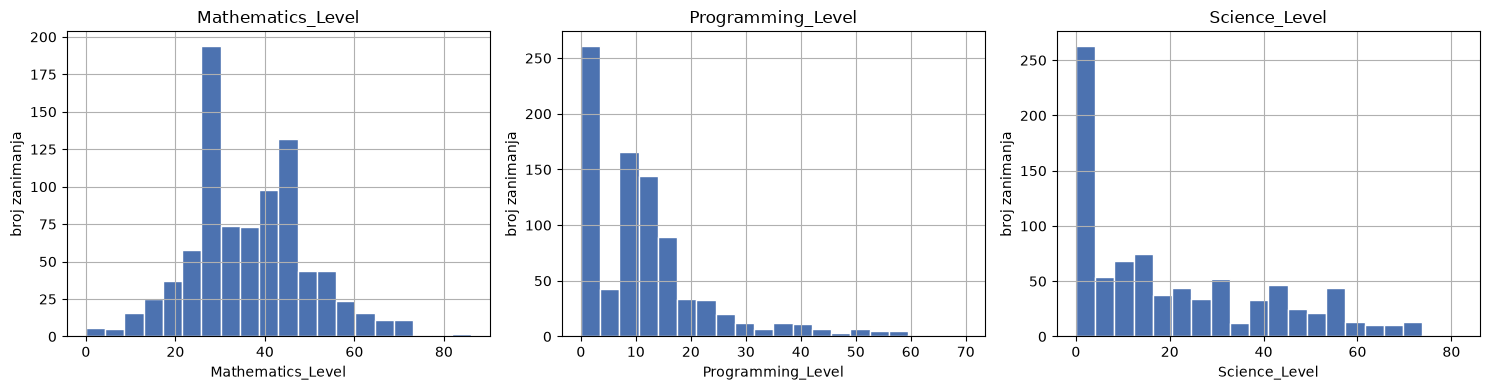

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Mathematics_Level', 'Programming_Level', 'Science_Level']):
    merged[col].dropna().hist(bins=20, ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('broj zanimanja')
plt.tight_layout()
plt.show()

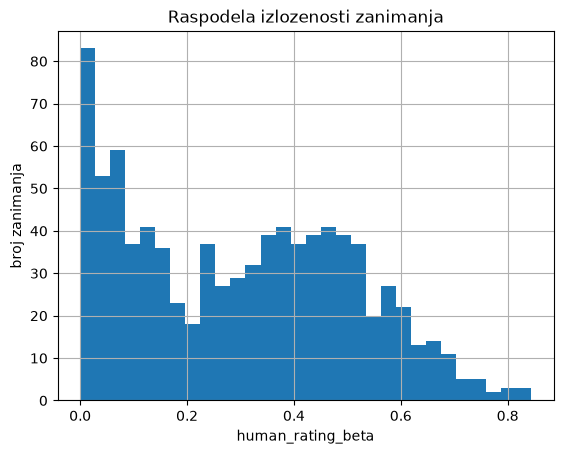

count    873.000000
mean       0.299480
std        0.208654
min        0.000000
25%        0.100000
50%        0.305195
75%        0.470588
max        0.843750
Name: human_rating_beta, dtype: float64

In [37]:
#Raspodela ciljne promenljive
merged['human_rating_beta'].hist(bins=30)
plt.xlabel('human_rating_beta')
plt.ylabel('broj zanimanja')
plt.title('Raspodela izlozenosti zanimanja')
plt.savefig('slike/01_histogram_target.png', dpi=300, bbox_inches='tight')
plt.show()

merged['human_rating_beta'].describe()

### 5.1. Korelaciona analiza

In [38]:
# Korelacije 
corr_data = X.copy()
corr_data[TARGET] = y
corr = (corr_data.corr()[TARGET].sort_values(ascending=False))
print(corr)

human_rating_beta                                1.000000
Reading_Comprehension_Importance                 0.737406
Writing_Importance                               0.730235
Writing_Level                                    0.722768
Speaking_Level                                   0.701128
Active_Listening_Level                           0.692029
Reading_Comprehension_Level                      0.690839
Active_Listening_Importance                      0.670890
Speaking_Importance                              0.665870
Critical_Thinking_Level                          0.658275
Active_Learning_Level                            0.617285
Job Zone                                         0.608348
Critical_Thinking_Importance                     0.582109
Active_Learning_Importance                       0.576083
Programming_Importance                           0.537885
Programming_Level                                0.522402
Learning_Strategies_Level                        0.496680
Mathematics_Le

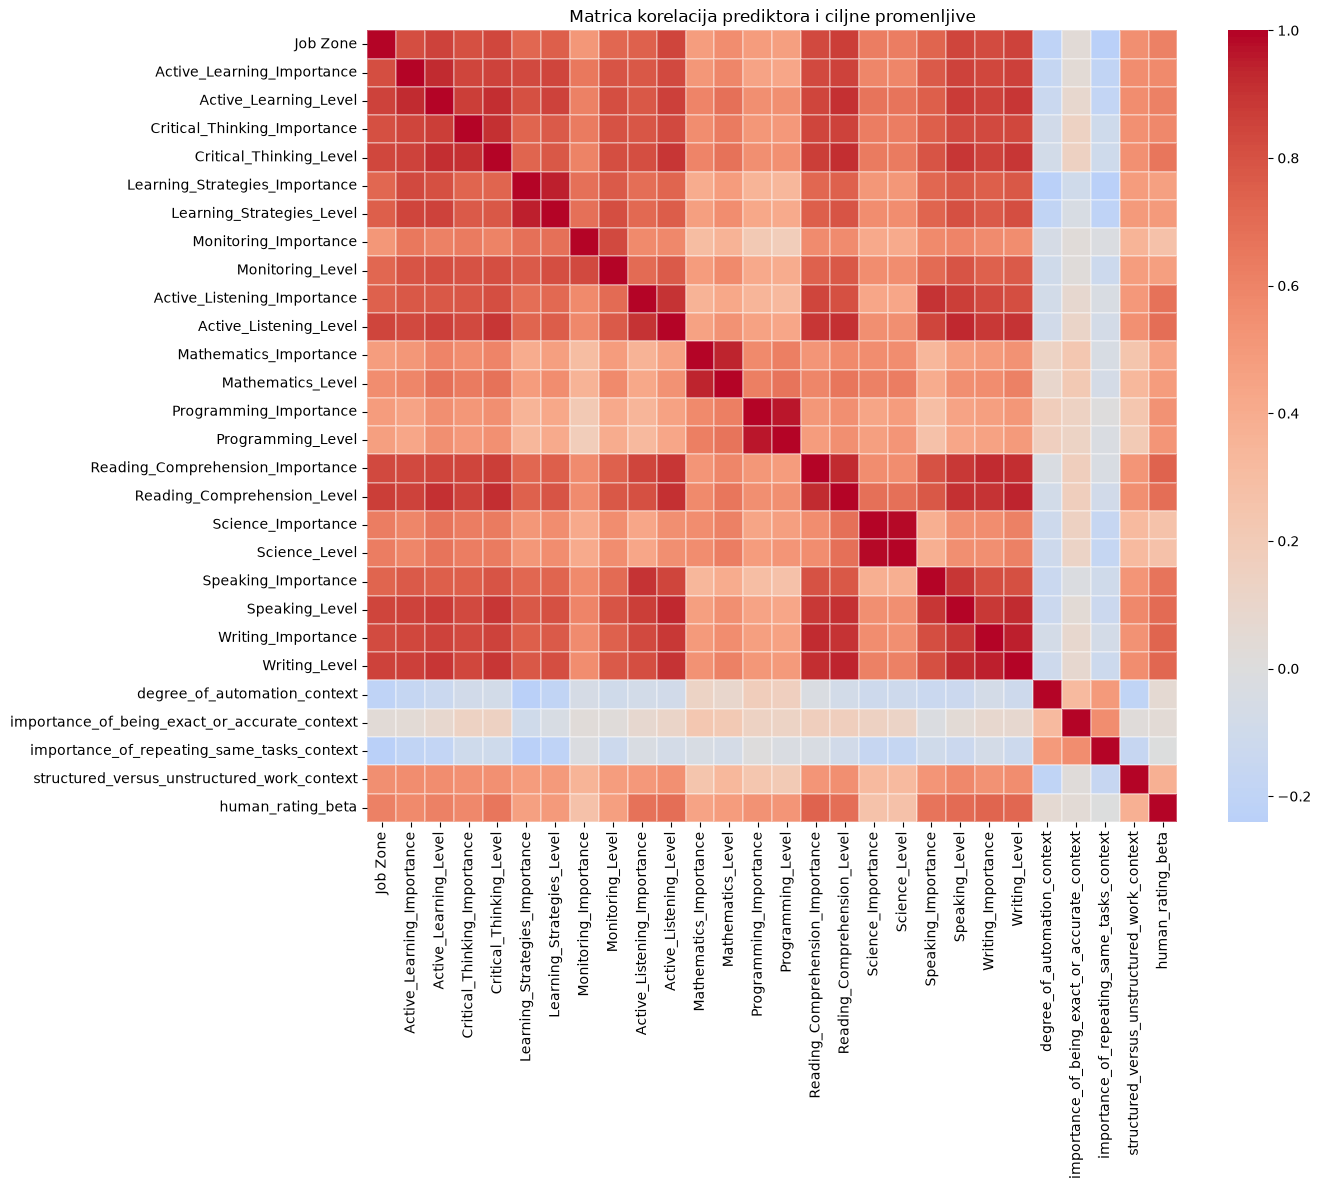

In [39]:
#Matrica korelacije prediktora
plt.figure(figsize=(14, 12))
sns.heatmap(corr_data.corr(), cmap='coolwarm', center=0, linewidths=0.1, linecolor=(1, 1, 1, 0.3))

plt.title('Matrica korelacija prediktora i ciljne promenljive')
plt.tight_layout()
plt.savefig('slike/02_heatmap_korelacije.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2. Analiza izloženosti zanimanja i odabranih karakteristika

In [40]:
#TOP 10 i BOTTOM 10 zanimanja po izlozenosti
print('TOP 10 zanimanja po izlozenosti')
print(merged[['Title', 'human_rating_beta']].sort_values('human_rating_beta', ascending=False).head(10))
print('\nBOTTOM 10 zanimanja po izlozenosti')
print(merged[['Title', 'human_rating_beta']].sort_values('human_rating_beta').head(10))

TOP 10 zanimanja po izlozenosti
                                                 Title  human_rating_beta
207                                 Survey Researchers           0.843750
177                                  Animal Scientists           0.843750
342                       Interpreters and Translators           0.840000
340                                Writers and Authors           0.807692
555                                   Brokerage Clerks           0.800000
337                       Public Relations Specialists           0.787879
206                           Environmental Economists           0.776316
584    Legal Secretaries and Administrative Assistants           0.760870
199                     Climate Change Policy Analysts           0.750000
583  Executive Secretaries and Executive Administra...           0.743243

BOTTOM 10 zanimanja po izlozenosti
                                                 Title  human_rating_beta
870                                   Wellhe

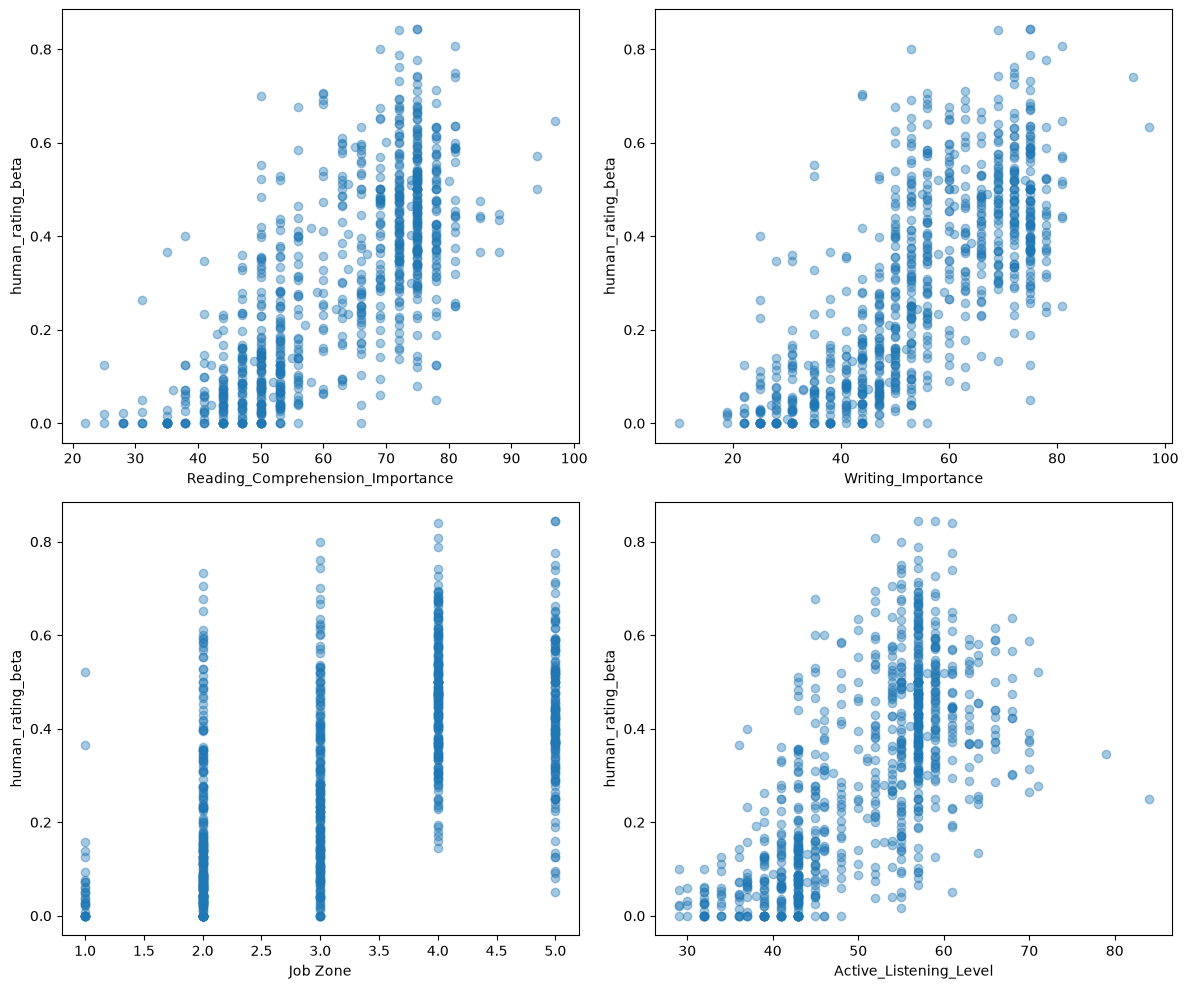

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['Reading_Comprehension_Importance', 'Writing_Importance', 'Job Zone', 'Active_Listening_Level']
for ax, feat in zip(axes.flatten(), features):
    ax.scatter(merged[feat], merged['human_rating_beta'], alpha=0.4)
    ax.set_xlabel(feat)
    ax.set_ylabel('human_rating_beta')
plt.tight_layout()
plt.savefig('slike/03_scatter_top_osobine.png', dpi=300, bbox_inches='tight')
plt.show()

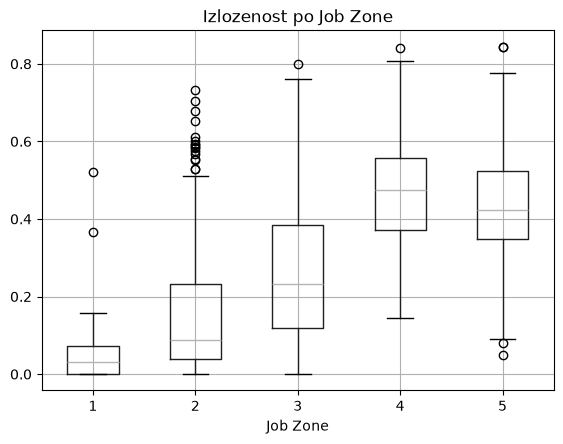

In [42]:
#Raspodela ciljne promenljive po Job Zone
merged.boxplot(column='human_rating_beta',by='Job Zone')
plt.title('Izlozenost po Job Zone')
plt.suptitle('')
plt.savefig('slike/04_boxplot_jobzone.png', dpi=300, bbox_inches='tight')
plt.show()

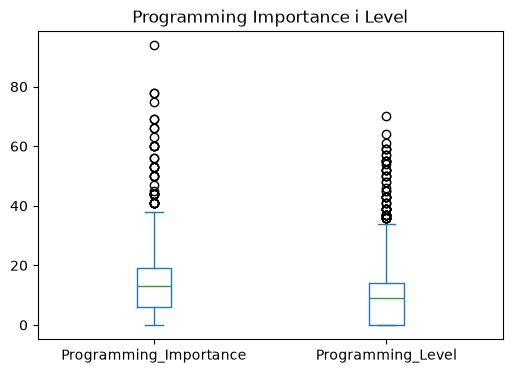

In [43]:
merged[['Programming_Importance', 'Programming_Level']].plot(kind='box', figsize=(6,4))
plt.title('Programming Importance i Level')
plt.savefig('slike/05_boxplot_programming_outlieri.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
skill_cols = [c for c in X.columns if 'Importance' in c or 'Level' in c]
for col in skill_cols:
    Q1 = merged[col].quantile(0.25)
    Q3 = merged[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((merged[col] < lower) | (merged[col] > upper)).sum()
    if n_outliers > 0:
        print(f"{col}: {n_outliers} outliera")

Critical_Thinking_Level: 1 outliera
Learning_Strategies_Level: 14 outliera
Monitoring_Importance: 1 outliera
Monitoring_Level: 1 outliera
Active_Listening_Level: 2 outliera
Mathematics_Importance: 5 outliera
Mathematics_Level: 19 outliera
Programming_Importance: 42 outliera
Programming_Level: 53 outliera
Reading_Comprehension_Level: 1 outliera
Science_Importance: 2 outliera
Writing_Level: 1 outliera


## 6. Analiza multikolinearnosti
Za procenu multikolinearnosti između prediktora korišćen je faktor inflacije varijanse (VIF). Visoke vrednosti VIF-a očekivane su kod pojedinih O*NET atributa zbog povezanosti mera važnosti i nivoa veština. 

In [45]:
#VIF
from statsmodels.tools.tools import add_constant

vif_data = X.copy()  
vif_data = vif_data.fillna(vif_data.median())
vif_matrix = add_constant(vif_data)

vif = pd.DataFrame({
    'feature': vif_matrix.columns[1:],
    'VIF': [
        variance_inflation_factor(vif_matrix.values, i)
        for i in range(1, vif_matrix.shape[1])
    ]
})
print(vif.sort_values('VIF', ascending=False))

                                          feature        VIF
16                    Reading_Comprehension_Level  20.427677
22                                  Writing_Level  18.876196
17                             Science_Importance  16.817730
18                                  Science_Level  16.267073
20                                 Speaking_Level  16.076787
2                           Active_Learning_Level  14.803780
6                       Learning_Strategies_Level  13.906703
10                         Active_Listening_Level  13.831961
4                         Critical_Thinking_Level  13.172192
12                              Mathematics_Level  12.472923
21                             Writing_Importance  12.170983
5                  Learning_Strategies_Importance  11.794912
15               Reading_Comprehension_Importance  11.790091
14                              Programming_Level  11.000965
13                         Programming_Importance  10.475269
11                      

## 7. Podela podataka - train/test split


In [46]:
#Train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

# CV za unutar trening skupa
cv = KFold(n_splits=5, shuffle=True, random_state=42)

(698, 27) (175, 27)


In [47]:
#Funkcija za evaluaciju modela
results = {}

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    spearman, _ = spearmanr(y_test, y_pred)

    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Spearman': spearman
    }

    print(name)
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}")
    print(f"R2:       {r2:.4f}")
    print(f"Spearman: {spearman:.4f}")

    return y_pred

## 8. Razvoj i optimizacija modela

### 8.1. Ridge regresija

In [48]:

ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

ridge_param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

print("Najbolji parametri:", ridge_search.best_params_)

y_pred_ridge = evaluate_model(
    'Ridge',
    ridge_search.best_estimator_,
    X_test,
    y_test
)

Najbolji parametri: {'model__alpha': 10.0}
Ridge
MAE:      0.0905
RMSE:     0.1159
R2:       0.6832
Spearman: 0.8376


### 8.2. Random Forest

In [49]:

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(random_state=42))
])

rf_param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Najbolji parametri:", rf_search.best_params_)

y_pred_rf = evaluate_model(
    'Random Forest',
    rf_search.best_estimator_,
    X_test,
    y_test
)

Najbolji parametri: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': None}
Random Forest
MAE:      0.0851
RMSE:     0.1120
R2:       0.7043
Spearman: 0.8497


### 8.3. XGBoost

In [50]:

xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ))
])

xgb_param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha': [0, 0.1, 1],
    'model__reg_lambda': [1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=cv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Najbolji parametri:", xgb_search.best_params_)

y_pred_xgb = evaluate_model(
    'XGBoost',
    xgb_search.best_estimator_,
    X_test,
    y_test
)

Najbolji parametri: {'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
XGBoost
MAE:      0.0842
RMSE:     0.1126
R2:       0.7007
Spearman: 0.8473


### 8.4. CatBoost

In [51]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', CatBoostRegressor(
        random_state=42,
        verbose=0,
        allow_writing_files=False,       
        thread_count=1
    ))
])

cat_param_dist = {
    'model__iterations': [100, 200, 300, 500],
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__l2_leaf_reg': [1, 3, 5, 10],
    'model__subsample': [0.6, 0.8, 1.0]
}

cat_search = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=cat_param_dist,
    n_iter=30,
    cv=cv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

print("Najbolji parametri:", cat_search.best_params_)

y_pred_cat = evaluate_model(
    'CatBoost',
    cat_search.best_estimator_,
    X_test,
    y_test
)

Najbolji parametri: {'model__subsample': 0.8, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 3, 'model__iterations': 500, 'model__depth': 8}
CatBoost
MAE:      0.0832
RMSE:     0.1088
R2:       0.7207
Spearman: 0.8518


### 8.5. Neuronska mreža

In [52]:

mlp_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        solver='adam',
        early_stopping=True,
        validation_fraction=0.20,
        n_iter_no_change=20,
        max_iter=2000,
        random_state=42
    ))
])

mlp_param_dist = {
    'model__hidden_layer_sizes': [
        (32,),
        (64,),
        (32, 16),
        (64, 32),
        (128, 64)
    ],
    'model__alpha': [
        0.0001,
        0.001,
        0.01,
        0.1,
        1.0
    ],
    'model__learning_rate_init': [
        0.0001,
        0.001,
        0.01
    ],
    'model__activation': [
        'relu',
        'tanh'
    ]
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=mlp_param_dist,
    n_iter=30,
    cv=cv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

mlp_search.fit(X_train, y_train)

print("Najbolji parametri:", mlp_search.best_params_)

y_pred_mlp = evaluate_model(
    'Neural Network',
    mlp_search.best_estimator_,
    X_test,
    y_test
)

Najbolji parametri: {'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (128, 64), 'model__alpha': 1.0, 'model__activation': 'relu'}
Neural Network
MAE:      0.0826
RMSE:     0.1078
R2:       0.7256
Spearman: 0.8561


## 9. Poređenje modela na test skupu


In [53]:
results_df = pd.DataFrame(results).T  
results_df = results_df.round(4)
results_df = results_df.sort_values('MAE', ascending=True)

results_df

,MAE,RMSE,R2,Spearman
Neural Network,0.0826,0.1078,0.7256,0.8561
CatBoost,0.0832,0.1088,0.7207,0.8518
XGBoost,0.0842,0.1126,0.7007,0.8473
Random Forest,0.0851,0.1120,0.7043,0.8497
Ridge,0.0905,0.1159,0.6832,0.8376


## 10. 5-FOLD CROSS-VALIDATION
Radi dodatne procene stabilnosti podešenih modela sprovedena je petostruka unakrsna validacija na trening skupu. Prikazane su srednje vrednosti i standardne devijacije MAE, RMSE i R² metrike.

In [54]:
tuned_models = {
    'Ridge': ridge_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_,
    'XGBoost': xgb_search.best_estimator_,
    'CatBoost': cat_search.best_estimator_,
    'Neural Network': mlp_search.best_estimator_
}

scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

cv_results = {}

for name, model in tuned_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[name] = {
        'MAE_mean': -scores['test_MAE'].mean(),
        'MAE_std': scores['test_MAE'].std(),

        'RMSE_mean': -scores['test_RMSE'].mean(),
        'RMSE_std': scores['test_RMSE'].std(),

        'R2_mean': scores['test_R2'].mean(),
        'R2_std': scores['test_R2'].std()
    }

cv_results_df = pd.DataFrame(cv_results).T.round(4).sort_values('R2_mean', ascending=False)

cv_results_df

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
CatBoost,0.0780,0.0067,0.1022,0.0099,0.7587,0.0383
XGBoost,0.0792,0.0067,0.1034,0.0109,0.7532,0.0408
Neural Network,0.0807,0.0065,0.1039,0.0110,0.7509,0.0409
Random Forest,0.0792,0.0061,0.1041,0.0096,0.7501,0.0356
Ridge,0.0878,0.0052,0.1112,0.0087,0.7153,0.0307


## 11. Detaljna analiza CatBoost modela

Na izdvojenom test skupu neuronska mreža ostvarila je neznatno bolje rezultate, dok je CatBoost pokazao najbolje prosečne performanse u petostrukoj unakrsnoj validaciji na trening skupu. Zbog stabilnih performansi i mogućnosti detaljne interpretacije primenom TreeSHAP metode, CatBoost je izabran za dalju analizu značaja prediktora i objašnjenje pojedinačnih predikcija.

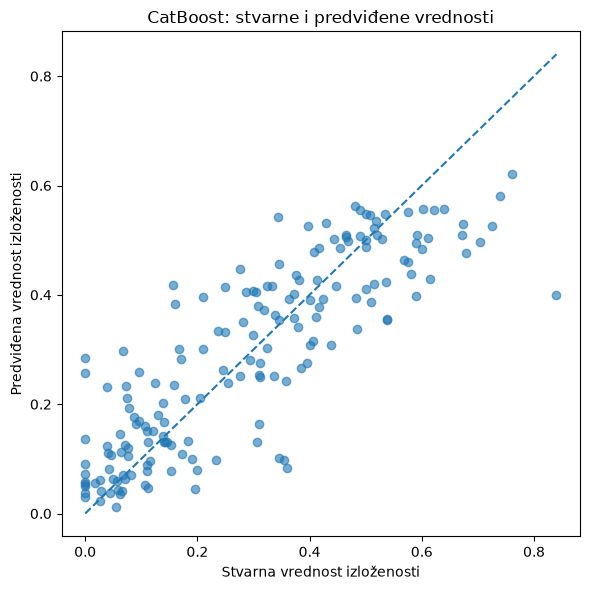

In [55]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred_cat,
    alpha=0.6
)

minimum = min(y_test.min(), y_pred_cat.min())
maximum = max(y_test.max(), y_pred_cat.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    '--',
    linewidth=1.5
)

plt.xlabel('Stvarna vrednost izloženosti')
plt.ylabel('Predviđena vrednost izloženosti')
plt.title('CatBoost: stvarne i predviđene vrednosti')

plt.tight_layout()

plt.savefig(
    'slike/06_catboost_actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

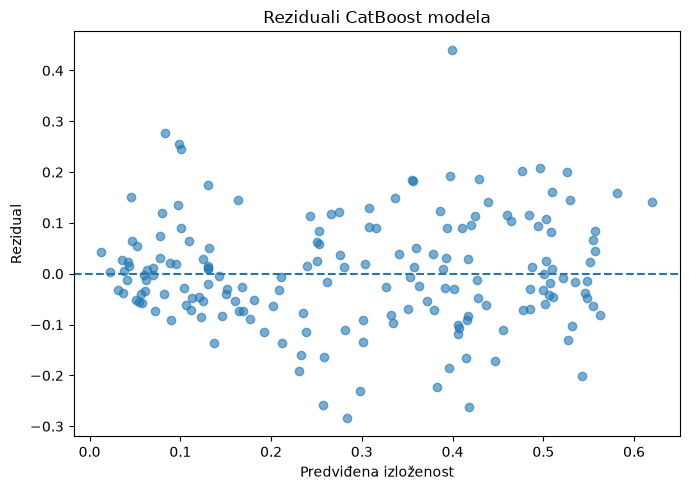

count    175.000000
mean       0.002127
std        0.109095
min       -0.283922
25%       -0.063655
50%       -0.007227
75%        0.065588
max        0.440749
Name: human_rating_beta, dtype: float64


In [56]:
residuals = y_test - y_pred_cat

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred_cat,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1.5
)

plt.xlabel('Predviđena izloženost')
plt.ylabel('Rezidual')
plt.title('Reziduali CatBoost modela')

plt.tight_layout()

plt.savefig(
    'slike/07_catboost_reziduali.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(pd.Series(residuals).describe())

## 12. Interpretacija modela
Pored procene tačnosti modela, sprovedena je analiza njegove interpretabilnosti. Korišćene su SHAP i LIME metode radi identifikovanja karakteristika koje najviše doprinose procenjenoj izloženosti zanimanja generativnoj veštačkoj inteligenciji.

### 12.1. SHAP analiza CatBoost modela

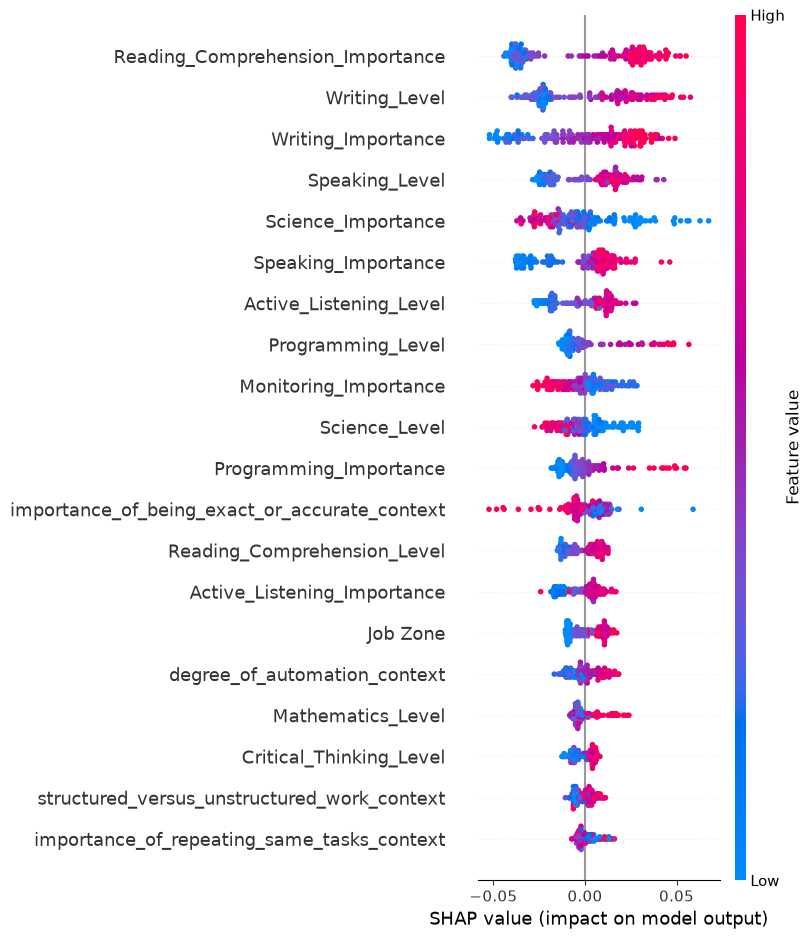

In [57]:

cat_imputer = cat_search.best_estimator_.named_steps['imputer']
cat_model = cat_search.best_estimator_.named_steps['model']

X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# TreeSHAP
explainer = shap.TreeExplainer(cat_model)

shap_values = explainer.shap_values(X_test_cat)

shap.summary_plot(
    shap_values,
    X_test_cat,
    show=False
)

plt.savefig(
    'slike/08_shap_summary_beeswarm.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

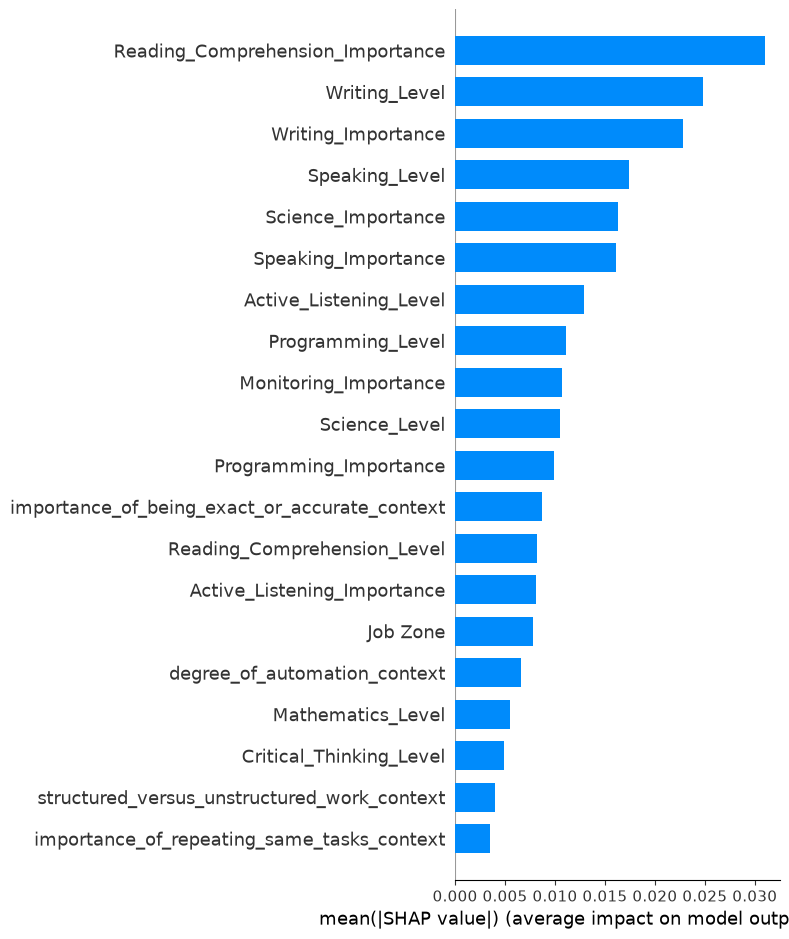

In [58]:
shap.summary_plot(
    shap_values,
    X_test_cat,
    plot_type='bar',
    show=False
)

plt.savefig(
    'slike/09_shap_summary_bar.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

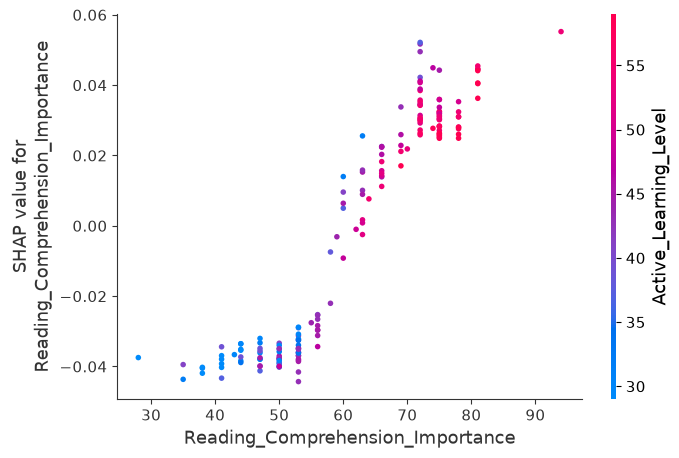

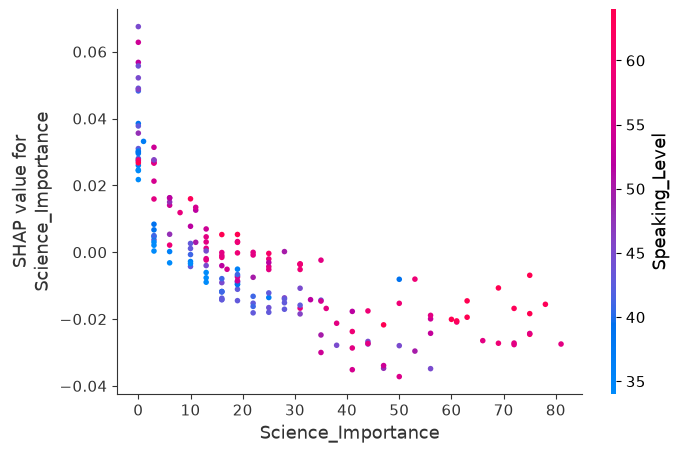

In [59]:
shap.dependence_plot(
    'Reading_Comprehension_Importance',
    shap_values,
    X_test_cat,
    show=False
)

plt.savefig(
    'slike/10_shap_dependence_reading.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

shap.dependence_plot(
    'Science_Importance',
    shap_values,
    X_test_cat,
    show=False
)

plt.savefig(
    'slike/11_shap_dependence_science.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Najviše predviđena izloženost:


,Title,y_true,y_pred
584,Legal Secretaries and Administrative Assistants,0.760870,0.620264
118,Biostatisticians,0.740000,0.581050
63,Cost Estimators,0.480769,0.562077
110,Geographic Information Systems Technologists a...,0.601852,0.557281
82,Budget Analysts,0.640000,0.556495
227,Social Science Research Assistants,0.621212,0.554827
72,Fundraisers,0.490385,0.554482
120,Clinical Data Managers,0.575000,0.551764
542,Sales Engineers,0.534091,0.548452
96,Computer and Information Research Scientists,0.500000,0.547619


Najniže predviđena izloženost:


,Title,y_true,y_pred
825,Helpers--Production Workers,0.055556,0.012773
650,Fence Erectors,0.025641,0.022855
664,"Roof Bolters, Mining",0.000000,0.030970
606,Logging Equipment Operators,0.062500,0.035336
644,"Helpers--Painters, Paperhangers, Plasterers, a...",0.000000,0.036856
820,"Stone Cutters and Carvers, Manufacturing",0.043478,0.037718
630,"Painters, Construction and Maintenance",0.028571,0.040761
851,Automotive and Watercraft Service Attendants,0.065217,0.042091
490,Maids and Housekeeping Cleaners,0.058824,0.043558
711,"Coin, Vending, and Amusement Machine Servicers...",0.196429,0.045383


Legal Secretaries and Administrative Assistants


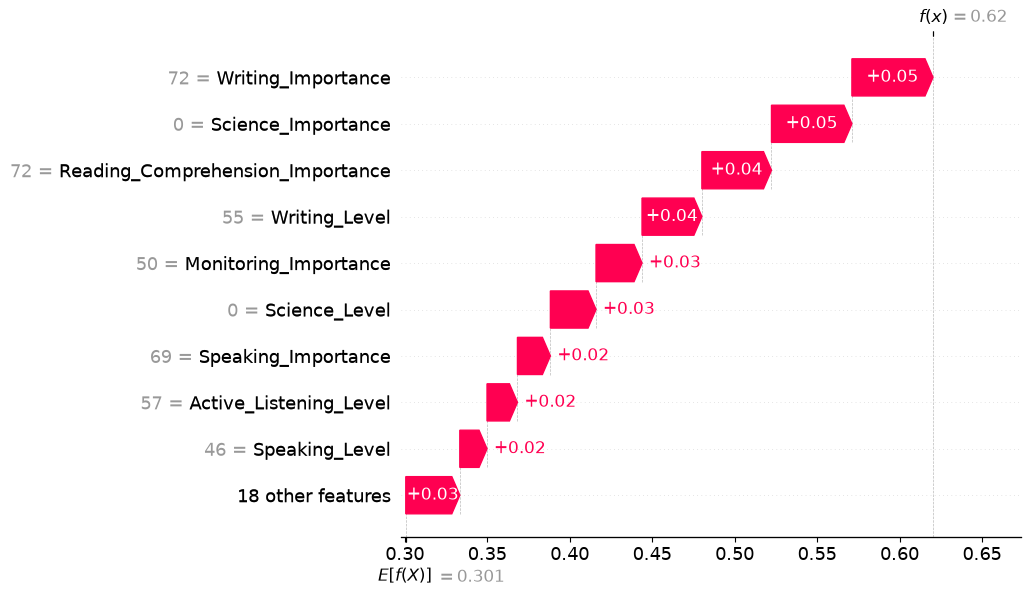

Helpers--Production Workers


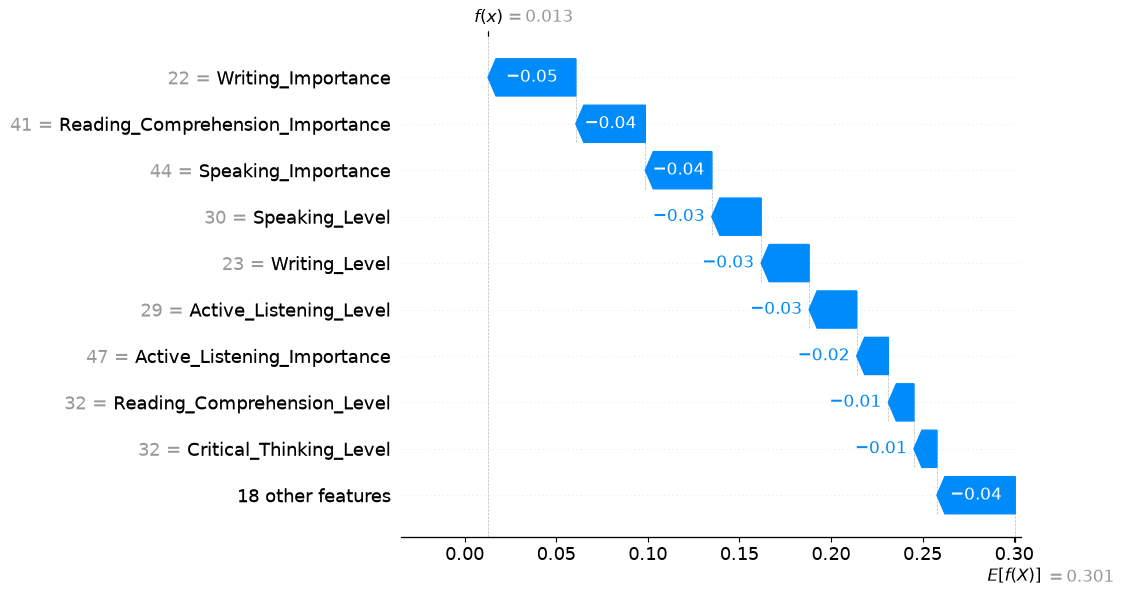

In [60]:
#waterfall grafikoni
test_titles = merged.loc[X_test.index, 'Title']

comparison = pd.DataFrame({
    'Title': test_titles,
    'y_true': y_test,
    'y_pred': y_pred_cat
}, index=X_test.index)

print("Najviše predviđena izloženost:")
display(
    comparison
    .sort_values('y_pred', ascending=False)
    .head(10)
)

print("Najniže predviđena izloženost:")
display(
    comparison
    .sort_values('y_pred')
    .head(10)
)

nazivi_fajlova = {
    584: '12_shap_waterfall_legal_secretaries.png',
    825: '13_shap_waterfall_helpers.png'
}

for odabrani_index, naziv in [
    (584, "Legal Secretaries and Administrative Assistants"),
    (825, "Helpers--Production Workers")
]:

    pozicija = X_test_cat.index.get_loc(odabrani_index)

    explanation = shap.Explanation(
        values=shap_values[pozicija],
        base_values=explainer.expected_value,
        data=X_test_cat.iloc[pozicija],
        feature_names=X_test_cat.columns
    )

    print(naziv)

    shap.waterfall_plot(
        explanation,
        show=False
    )

    plt.savefig(
        f'slike/{nazivi_fajlova[odabrani_index]}',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

### 12.2. LIME analiza CatBoost modela


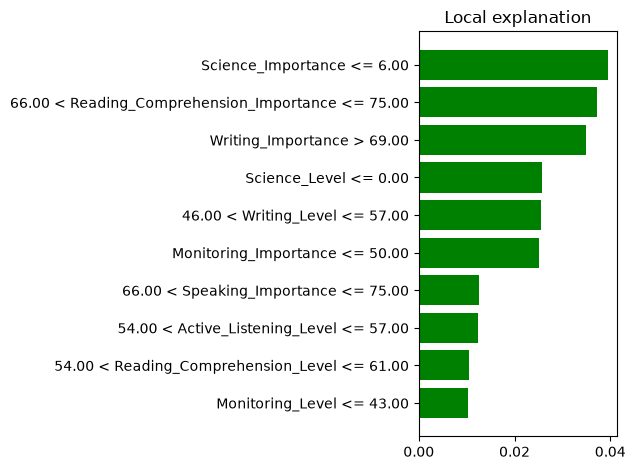

[('Science_Importance <= 6.00', 0.039459522553335645), ('66.00 < Reading_Comprehension_Importance <= 75.00', 0.037205497070341674), ('Writing_Importance > 69.00', 0.034984743004572015), ('Science_Level <= 0.00', 0.02580613429474031), ('46.00 < Writing_Level <= 57.00', 0.025512812634808514), ('Monitoring_Importance <= 50.00', 0.025080277954042315), ('66.00 < Speaking_Importance <= 75.00', 0.012605379353577119), ('54.00 < Active_Listening_Level <= 57.00', 0.012371600263573528), ('54.00 < Reading_Comprehension_Level <= 61.00', 0.010499992532647343), ('Monitoring_Level <= 43.00', 0.010365542728967385)]


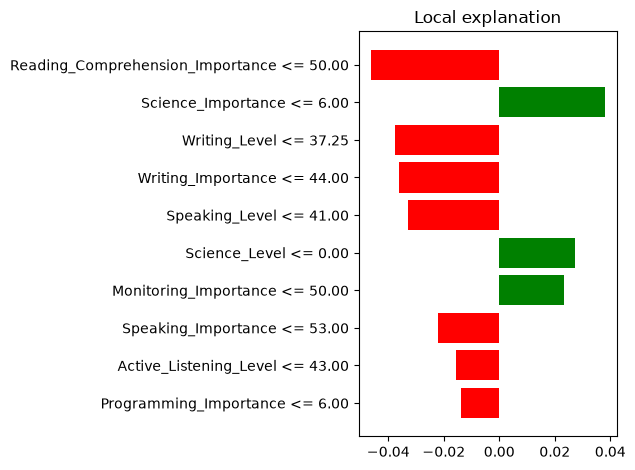

In [61]:
from lime.lime_tabular import LimeTabularExplainer

X_train_lime = pd.DataFrame(
    cat_imputer.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_lime = pd.DataFrame(
    cat_imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train_lime.columns.tolist(),
    mode='regression',
    random_state=42)

pozicija = X_test_lime.index.get_loc(584)

lime_exp = lime_explainer.explain_instance(
    X_test_lime.iloc[pozicija].values,
    cat_model.predict,
    num_features=10
)

fig = lime_exp.as_pyplot_figure()

plt.tight_layout()
plt.savefig('slike/14_lime_legal_secretaries.png', dpi=300, bbox_inches='tight')
plt.show()

print(lime_exp.as_list())

pozicija = X_test_lime.index.get_loc(825)

lime_exp = lime_explainer.explain_instance(
    X_test_lime.iloc[pozicija].values,
    cat_model.predict,
    num_features=10
)

fig = lime_exp.as_pyplot_figure()

plt.tight_layout()
plt.savefig('slike/15_lime_helpers.png', dpi=300, bbox_inches='tight')
plt.show()

### 12.3. SHAP analiza neuronske mreže

In [62]:
#priprema podataka za NN interpretaciju

nn_pipeline = mlp_search.best_estimator_
nn_imputer = nn_pipeline.named_steps['imputer']

X_train_nn = pd.DataFrame(
    nn_imputer.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_nn = pd.DataFrame(
    nn_imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)
def nn_predict(data):
    data_df = pd.DataFrame(
        np.asarray(data, dtype=float),
        columns=X.columns
    )

    return nn_pipeline.predict(data_df)

In [63]:
#SHAP Permutation Explainer
background_nn = X_train_nn.sample(
    n=min(30, len(X_train_nn)),
    random_state=42
)

nn_shap_explainer = shap.PermutationExplainer(
    nn_predict,
    background_nn,
    feature_names=X_train_nn.columns.tolist(),
    seed=42
)

shap_values_nn = nn_shap_explainer(
    X_test_nn,
    max_evals=100
)

PermutationExplainer explainer: 176it [00:23,  7.35it/s]                         


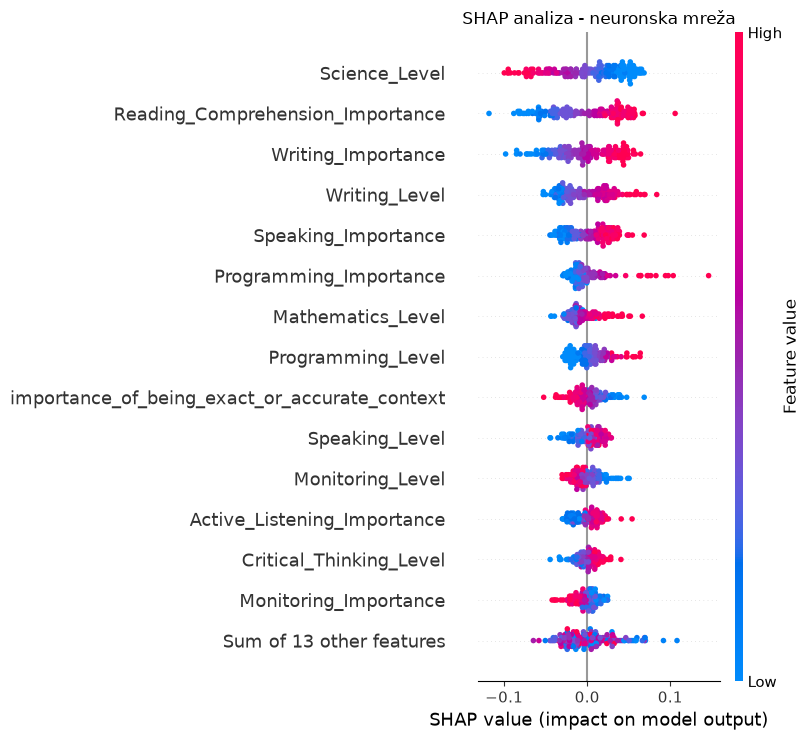

In [64]:
# NN SHAP beeswarm
shap.plots.beeswarm(
    shap_values_nn,
    max_display=15,
    show=False
)

plt.title('SHAP analiza - neuronska mreža')

plt.tight_layout()

plt.savefig(
    'slike/16_nn_shap_beeswarm.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

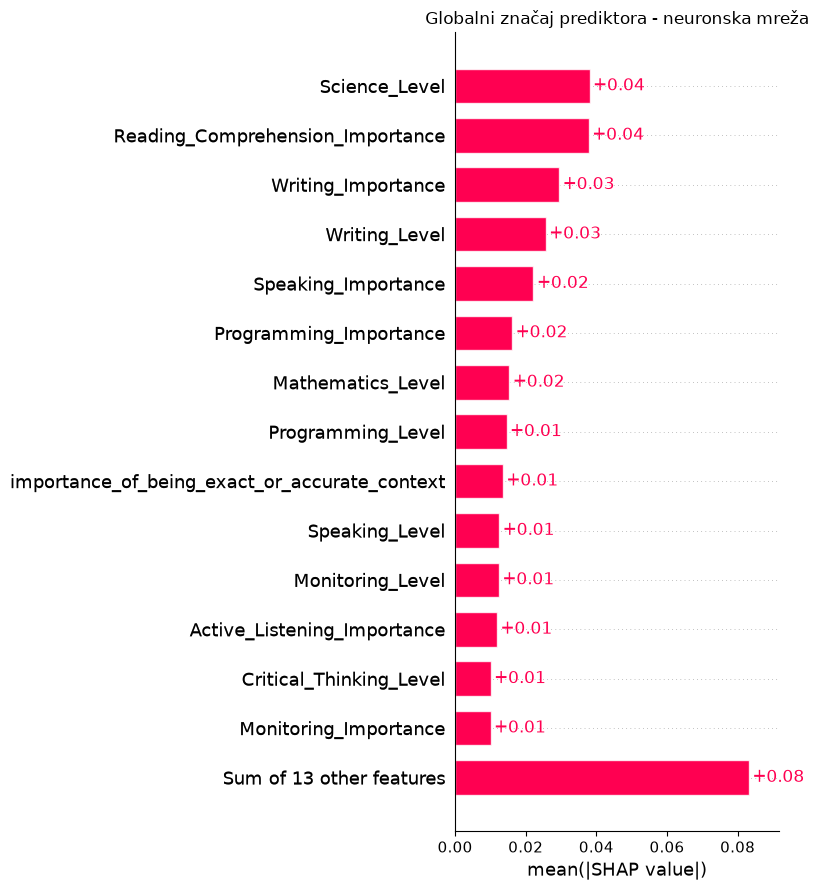

In [65]:
# NN SHAP bar
shap.plots.bar(
    shap_values_nn,
    max_display=15,
    show=False
)

plt.title('Globalni značaj prediktora - neuronska mreža')

plt.tight_layout()

plt.savefig(
    'slike/17_nn_shap_bar.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Legal Secretaries and Administrative Assistants
Predikcija neuronske mreže: 0.5528484045185154


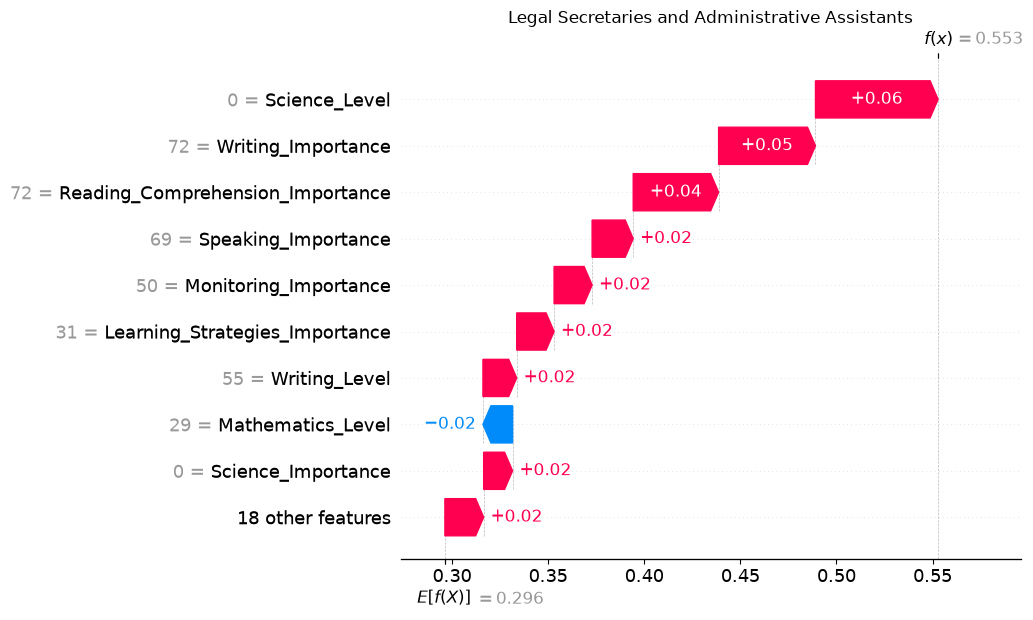

Helpers--Production Workers
Predikcija neuronske mreže: 0.022334183596712506


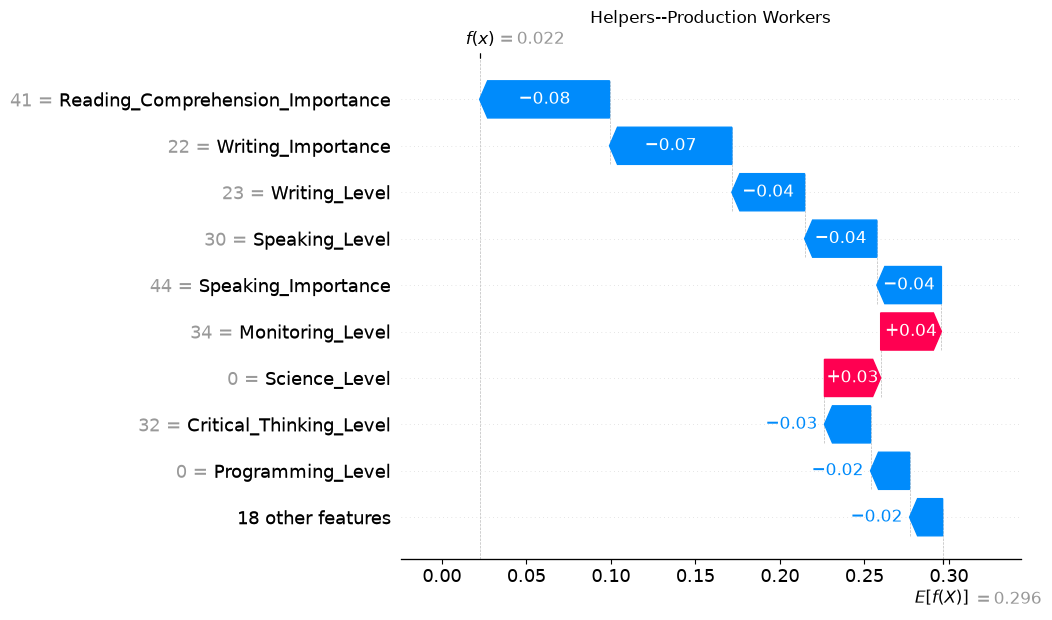

In [66]:
#SHAP waterfall
nn_waterfall_cases = [
    (
        584,
        'Legal Secretaries and Administrative Assistants',
        'slike/18_nn_shap_waterfall_legal_secretaries.png'
    ),
    (
        825,
        'Helpers--Production Workers',
        'slike/19_nn_shap_waterfall_helpers.png'
    )
]

for indeks, naziv, fajl in nn_waterfall_cases:

    local_shap = nn_shap_explainer(
        X_test_nn.loc[[indeks]],
        max_evals=200
    )

    print(naziv)
    print(
        "Predikcija neuronske mreže:",
        nn_predict(X_test_nn.loc[[indeks]])[0]
    )

    shap.plots.waterfall(
        local_shap[0],
        max_display=10,
        show=False
    )

    plt.title(naziv)

    plt.savefig(
        fajl,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

### 12.4. LIME analiza neuronske mreže


In [67]:
nn_lime_explainer = LimeTabularExplainer(
    training_data=X_train_nn.values,
    feature_names=X_train_nn.columns.tolist(),
    mode='regression',
    random_state=42
)

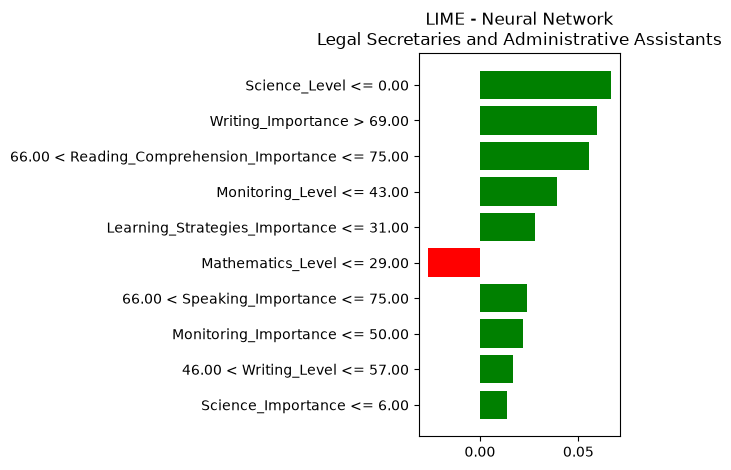

[('Science_Level <= 0.00', 0.06647264645631329), ('Writing_Importance > 69.00', 0.05924695238537067), ('66.00 < Reading_Comprehension_Importance <= 75.00', 0.05554592062326615), ('Monitoring_Level <= 43.00', 0.03909023072964393), ('Learning_Strategies_Importance <= 31.00', 0.028135730236011097), ('Mathematics_Level <= 29.00', -0.026397365481249317), ('66.00 < Speaking_Importance <= 75.00', 0.024129800622935123), ('Monitoring_Importance <= 50.00', 0.02166935481605918), ('46.00 < Writing_Level <= 57.00', 0.016694284202658845), ('Science_Importance <= 6.00', 0.013758545428876973)]


In [68]:
# LIME Legal Secretaries
indeks = 584

pozicija = X_test_nn.index.get_loc(indeks)

nn_lime_legal = nn_lime_explainer.explain_instance(
    X_test_nn.iloc[pozicija].values,
    nn_predict,
    num_features=10
)

fig = nn_lime_legal.as_pyplot_figure()

plt.title(
    'LIME - Neural Network\n'
    'Legal Secretaries and Administrative Assistants'
)

plt.tight_layout()

plt.savefig(
    'slike/20_nn_lime_legal_secretaries.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(nn_lime_legal.as_list())

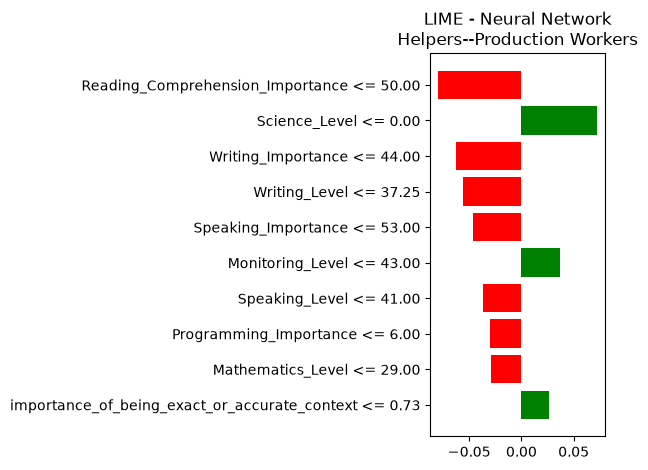

[('Reading_Comprehension_Importance <= 50.00', -0.07969121964103727), ('Science_Level <= 0.00', 0.07265854926241971), ('Writing_Importance <= 44.00', -0.06275814789261837), ('Writing_Level <= 37.25', -0.05558545368844932), ('Speaking_Importance <= 53.00', -0.046834046460432786), ('Monitoring_Level <= 43.00', 0.037289898348420975), ('Speaking_Level <= 41.00', -0.03722741118233577), ('Programming_Importance <= 6.00', -0.030050628096930397), ('Mathematics_Level <= 29.00', -0.028888622257628182), ('importance_of_being_exact_or_accurate_context <= 0.73', 0.026173028585696482)]


In [69]:
#LIME Helpers Production Workers
indeks = 825

pozicija = X_test_nn.index.get_loc(indeks)

nn_lime_helpers = nn_lime_explainer.explain_instance(
    X_test_nn.iloc[pozicija].values,
    nn_predict,
    num_features=10
)

fig = nn_lime_helpers.as_pyplot_figure()

plt.title(
    'LIME - Neural Network\n'
    'Helpers--Production Workers'
)

plt.tight_layout()

plt.savefig(
    'slike/21_nn_lime_helpers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(nn_lime_helpers.as_list())

## 13. Analiza značaja prediktora


In [70]:
rf_model = rf_search.best_estimator_.named_steps['model']
xgb_model = xgb_search.best_estimator_.named_steps['model']

rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Random Forest - Top 10")
display(rf_importances.head(10))

print("XGBoost - Top 10")
display(xgb_importances.head(10))

Random Forest - Top 10


Reading_Comprehension_Importance                 0.238809
Writing_Level                                    0.153844
Speaking_Level                                   0.146768
Writing_Importance                               0.064710
Science_Importance                               0.043467
Speaking_Importance                              0.038694
Active_Listening_Level                           0.033273
importance_of_being_exact_or_accurate_context    0.031379
Monitoring_Importance                            0.026167
Science_Level                                    0.024855
dtype: float64

XGBoost - Top 10


Reading_Comprehension_Importance    0.282496
Speaking_Level                      0.215370
Writing_Level                       0.144367
Speaking_Importance                 0.034544
Science_Importance                  0.032927
Reading_Comprehension_Level         0.031618
Writing_Importance                  0.027362
Monitoring_Importance               0.026753
Active_Listening_Level              0.019683
Programming_Level                   0.019299
dtype: float32

Permutation importance - Top 10:


Writing_Level                                    0.017286
Reading_Comprehension_Importance                 0.015985
Writing_Importance                               0.015196
Speaking_Level                                   0.009628
Speaking_Importance                              0.008488
Science_Importance                               0.008444
Science_Level                                    0.004456
Active_Listening_Level                           0.004121
importance_of_being_exact_or_accurate_context    0.002398
Programming_Importance                           0.002020
dtype: float64

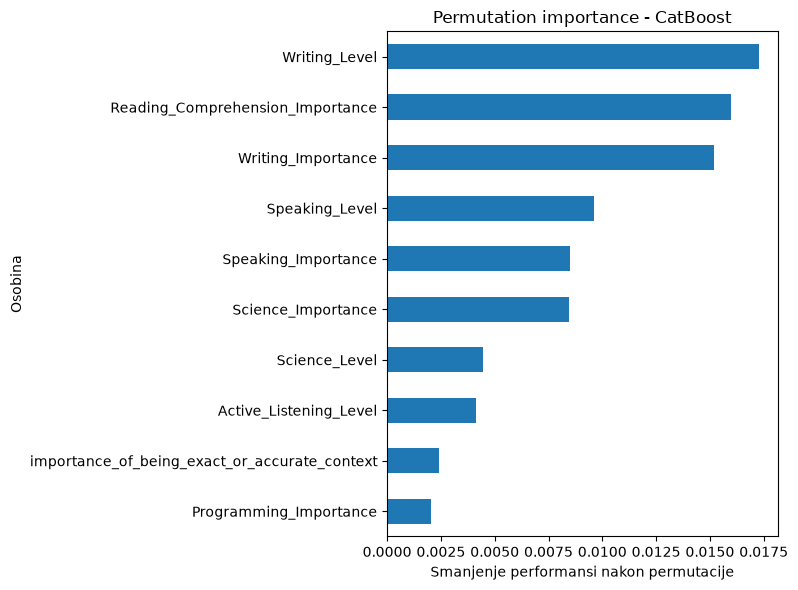

In [71]:
#Permutation Importance

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    cat_search.best_estimator_,
    X_test,
    y_test,
    n_repeats=30,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("Permutation importance - Top 10:")
display(perm_importance.head(10))

top_perm = perm_importance.head(10).sort_values()

plt.figure(figsize=(8, 6))

top_perm.plot(kind='barh')

plt.xlabel('Smanjenje performansi nakon permutacije')
plt.ylabel('Osobina')
plt.title('Permutation importance - CatBoost')

plt.tight_layout()

plt.savefig(
    'slike/22_permutation_importance_catboost.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

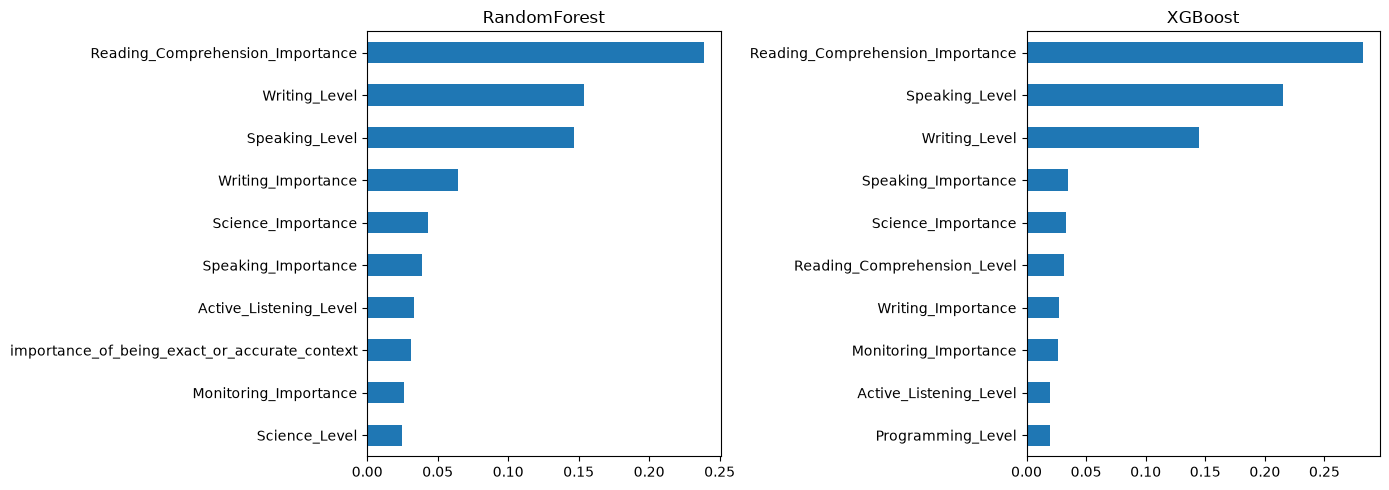

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rf_importances.sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[0], title='RandomForest')
xgb_importances.sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[1], title='XGBoost')
axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig('slike/23_feature_importance_rf_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Analiza procesa učenja neuronske mreže
Kriva funkcije gubitka prikazuje promenu greške tokom iterativnog treniranja neuronske mreže i omogućava uvid u proces konvergencije modela.

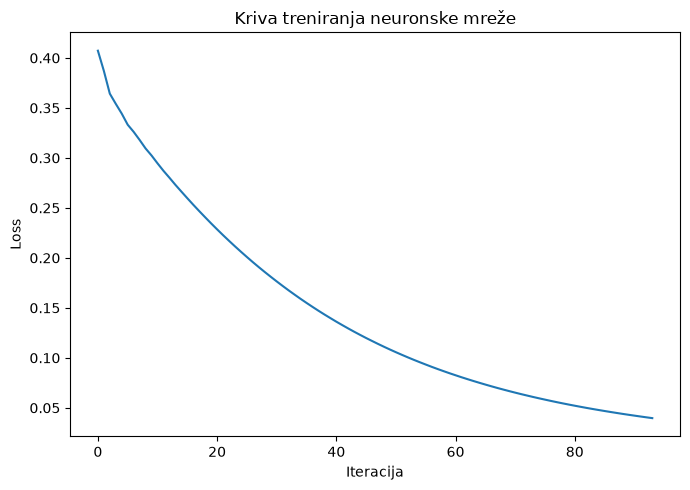

In [73]:
loss_curve = (
    mlp_search
    .best_estimator_
    .named_steps['model']
    .loss_curve_
)

plt.figure(figsize=(7, 5))

plt.plot(loss_curve)

plt.xlabel('Iteracija')
plt.ylabel('Loss')
plt.title('Kriva treniranja neuronske mreže')

plt.tight_layout()

plt.savefig(
    'slike/24_nn_loss_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 15. Finalni rezultati


In [74]:
print(sorted(os.listdir('slike')))

['01_histogram_target.png', '02_heatmap_korelacije.png', '03_scatter_top_osobine.png', '04_boxplot_jobzone.png', '05_boxplot_programming_outlieri.png', '06_catboost_actual_vs_predicted.png', '07_catboost_reziduali.png', '08_shap_summary_beeswarm.png', '09_shap_summary_bar.png', '10_shap_dependence_reading.png', '11_shap_dependence_science.png', '12_shap_waterfall_legal_secretaries.png', '13_shap_waterfall_helpers.png', '14_lime_legal_secretaries.png', '15_lime_helpers.png', '16_nn_shap_beeswarm.png', '17_nn_shap_bar.png', '18_nn_shap_waterfall_legal_secretaries.png', '19_nn_shap_waterfall_helpers.png', '20_nn_lime_legal_secretaries.png', '21_nn_lime_helpers.png', '22_permutation_importance_catboost.png', '23_feature_importance_rf_xgb.png', '24_nn_loss_curve.png', '25_tabela_poredjenje_modela.png', 'rezultati_5fold_cv_trening.csv', 'rezultati_test_skup.csv']


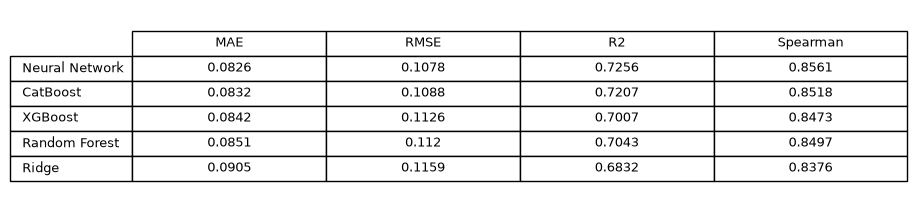

In [75]:

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')
tabela = ax.table(cellText=results_df.values,
                   rowLabels=results_df.index,
                   colLabels=results_df.columns,
                   cellLoc='center', loc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1, 1.5)
plt.savefig('slike/25_tabela_poredjenje_modela.png', dpi=300, bbox_inches='tight')
plt.show()

In [76]:
results_df.to_csv(
    'slike/rezultati_test_skup.csv'
)

cv_results_df.to_csv(
    'slike/rezultati_5fold_cv_trening.csv'
)

print("Tabele su sačuvane.")

Tabele su sačuvane.
